### Project Overview

This project implements a simplified deep learning approach for
pixel-wise flood susceptibility prediction using synthetic
geospatial data inspired by the research paper:

"Urban Flood Susceptibility Assessment in Arid Environment
Using a Novel Hybrid Deep Learning Approach"

The implementation compares two approaches:

1. CNN-based spatial feature extraction
2. CNN + Transformer/Attention for spatial context

The goal is to understand and demonstrate the core methodology
rather than reproduce the complete research study.

### Importing Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn
import torch
import torchvision

###  Load and Inspect the Dataset

In [5]:
import numpy as np

data = np.load("sharjah_synthetic_flood_dataset.npz")

X = data["X"]
Y = data["Y"]

print("Input shape (X):", X.shape)
print("Target shape (Y):", Y.shape)

Input shape (X): (500, 9, 64, 64)
Target shape (Y): (500, 64, 64)


### Data Preprocessing

In [13]:
from sklearn.model_selection import train_test_split


X_train, X_temp, Y_train, Y_temp = train_test_split(
    X, Y,
    test_size=0.30,
    random_state=42
)


X_val, X_test, Y_val, Y_test = train_test_split(
    X_temp, Y_temp,
    test_size=0.50,
    random_state=42
)

print("Training:", X_train.shape, Y_train.shape)
print("Validation:", X_val.shape, Y_val.shape)
print("Testing:", X_test.shape, Y_test.shape)

Training: (350, 9, 64, 64) (350, 64, 64)
Validation: (75, 9, 64, 64) (75, 64, 64)
Testing: (75, 9, 64, 64) (75, 64, 64)


### Feature Normalization

In [16]:
train_min = X_train.min(axis=(0, 2, 3), keepdims=True)
train_max = X_train.max(axis=(0, 2, 3), keepdims=True)

denominator = train_max - train_min
denominator[denominator == 0] = 1

X_train = (X_train - train_min) / denominator
X_val = (X_val - train_min) / denominator
X_test = (X_test - train_min) / denominator

print("Training range:", X_train.min(), "to", X_train.max())
print("Validation range:", X_val.min(), "to", X_val.max())
print("Test range:", X_test.min(), "to", X_test.max())

Training range: 0.0 to 1.0
Validation range: 0.0 to 1.0
Test range: 0.0 to 1.0293097


### PyTorch Dataset & DataLoader

In [19]:
import torch
from torch.utils.data import Dataset, DataLoader


class FloodDataset(Dataset):

    def __init__(self, X, Y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.Y = torch.tensor(Y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, index):
        return self.X[index], self.Y[index]


train_dataset = FloodDataset(X_train, Y_train)
val_dataset = FloodDataset(X_val, Y_val)
test_dataset = FloodDataset(X_test, Y_test)


train_loader = DataLoader(
    train_dataset,
    batch_size=16,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=16,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=16,
    shuffle=False
)

print("Training batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Testing batches:", len(test_loader))

Training batches: 22
Validation batches: 5
Testing batches: 5


In [21]:
X_batch, Y_batch = next(iter(train_loader))

print("Input batch shape:", X_batch.shape)
print("Target batch shape:", Y_batch.shape)

Input batch shape: torch.Size([16, 9, 64, 64])
Target batch shape: torch.Size([16, 64, 64])


### Build the CNN baseline

In [25]:
import torch
import torch.nn as nn


class FloodCNN(nn.Module):

    def __init__(self):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Conv2d(9, 32, kernel_size=3, padding=1),
            nn.ReLU(),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),

            nn.Conv2d(64, 32, kernel_size=3, padding=1),
            nn.ReLU()
        )

        self.output_layer = nn.Conv2d(
            32, 1, kernel_size=1
        )

    def forward(self, x):
        x = self.encoder(x)
        x = self.output_layer(x)

        return x


# Create the model
cnn_model = FloodCNN()

print(cnn_model)

FloodCNN(
  (encoder): Sequential(
    (0): Conv2d(9, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): Conv2d(64, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): ReLU()
  )
  (output_layer): Conv2d(32, 1, kernel_size=(1, 1), stride=(1, 1))
)


In [27]:
# Take one batch from the DataLoader
X_batch, Y_batch = next(iter(train_loader))

# Pass it through the CNN
output = cnn_model(X_batch)

print("Input shape:", X_batch.shape)
print("Output shape:", output.shape)

Input shape: torch.Size([16, 9, 64, 64])
Output shape: torch.Size([16, 1, 64, 64])


### Training Setup

In [30]:
criterion = nn.BCEWithLogitsLoss()

optimizer = torch.optim.Adam(
    cnn_model.parameters(),
    lr=0.001
)

print("Loss function:", criterion)
print("Optimizer:", optimizer)

Loss function: BCEWithLogitsLoss()
Optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)


### Train the CNN Baseline

In [33]:
num_epochs = 10

train_losses = []
val_losses = []

for epoch in range(num_epochs):

    cnn_model.train()

    running_train_loss = 0.0

    for X_batch, Y_batch in train_loader:

        predictions = cnn_model(X_batch)

        predictions = predictions.squeeze(1)

        loss = criterion(predictions, Y_batch)

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

        running_train_loss += loss.item()

    avg_train_loss = running_train_loss / len(train_loader)


    cnn_model.eval()

    running_val_loss = 0.0

    with torch.no_grad():

        for X_batch, Y_batch in val_loader:

            predictions = cnn_model(X_batch)
            predictions = predictions.squeeze(1)

            loss = criterion(predictions, Y_batch)

            running_val_loss += loss.item()

    avg_val_loss = running_val_loss / len(val_loader)

    train_losses.append(avg_train_loss)
    val_losses.append(avg_val_loss)

    print(
        f"Epoch [{epoch+1}/{num_epochs}] "
        f"Train Loss: {avg_train_loss:.4f} "
        f"Val Loss: {avg_val_loss:.4f}"
    )

Epoch [1/10] Train Loss: 0.5458 Val Loss: 0.3530
Epoch [2/10] Train Loss: 0.2762 Val Loss: 0.2551
Epoch [3/10] Train Loss: 0.2504 Val Loss: 0.2475
Epoch [4/10] Train Loss: 0.2455 Val Loss: 0.2344
Epoch [5/10] Train Loss: 0.2381 Val Loss: 0.2337
Epoch [6/10] Train Loss: 0.2347 Val Loss: 0.2283
Epoch [7/10] Train Loss: 0.2295 Val Loss: 0.2391
Epoch [8/10] Train Loss: 0.2345 Val Loss: 0.2264
Epoch [9/10] Train Loss: 0.2275 Val Loss: 0.2196
Epoch [10/10] Train Loss: 0.2187 Val Loss: 0.2106


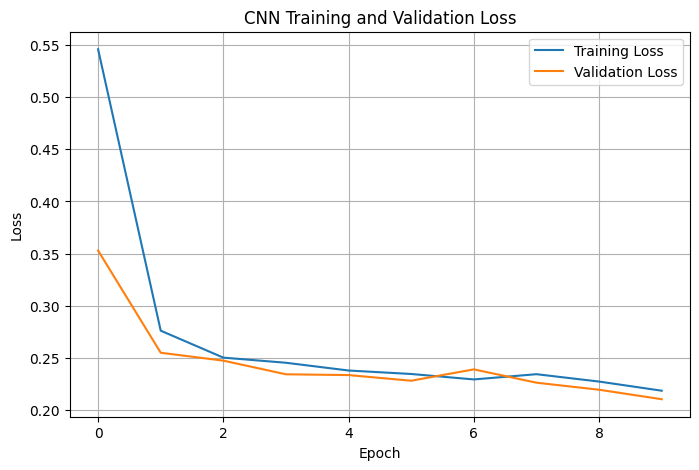

In [35]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(train_losses, label="Training Loss")
plt.plot(val_losses, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("CNN Training and Validation Loss")
plt.legend()
plt.grid(True)

plt.show()

### CNN Test Evaluation

In [40]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    jaccard_score
)

cnn_model.eval()

all_predictions = []
all_targets = []

with torch.no_grad():

    for X_batch, Y_batch in test_loader:

        logits = cnn_model(X_batch).squeeze(1)

        # Convert logits to probabilities
        probabilities = torch.sigmoid(logits)

        # Convert probabilities to binary predictions
        predictions = (probabilities >= 0.5).float()

        all_predictions.append(predictions.cpu().numpy())
        all_targets.append(Y_batch.cpu().numpy())


# Combine all batches
all_predictions = np.concatenate(all_predictions)
all_targets = np.concatenate(all_targets)

# Flatten pixel predictions
y_pred = all_predictions.flatten()
y_true = all_targets.flatten()

# Calculate metrics
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, zero_division=0)
recall = recall_score(y_true, y_pred, zero_division=0)
f1 = f1_score(y_true, y_pred, zero_division=0)
iou = jaccard_score(y_true, y_pred, zero_division=0)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"IoU      : {iou:.4f}")

Accuracy : 0.9083
Precision: 0.8705
Recall   : 0.7902
F1 Score : 0.8284
IoU      : 0.7070


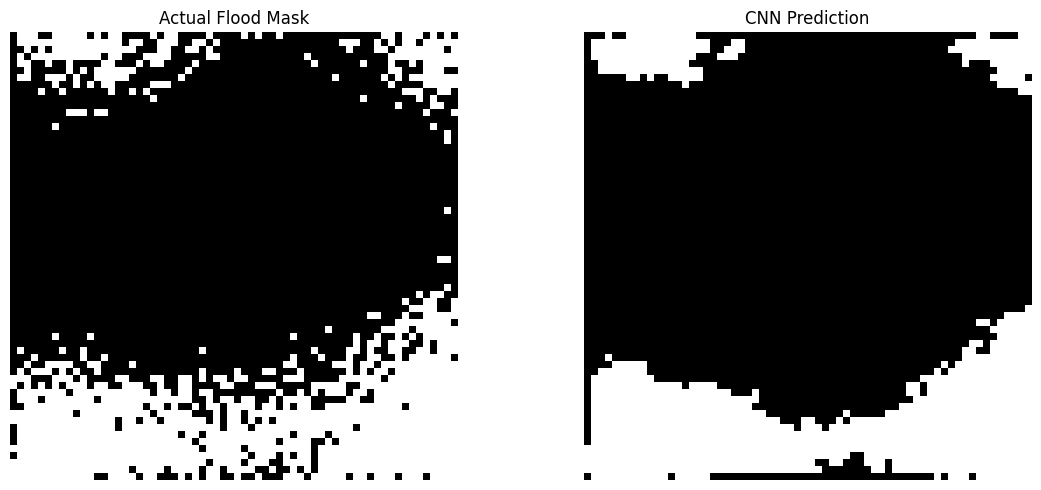

In [42]:
# Select one test sample
sample_index = 0

sample_input = torch.tensor(
    X_test[sample_index:sample_index + 1],
    dtype=torch.float32
)

# Generate prediction
cnn_model.eval()

with torch.no_grad():
    logits = cnn_model(sample_input).squeeze(1)
    probability = torch.sigmoid(logits)
    prediction = (probability >= 0.5).float()

# Convert to NumPy
predicted_mask = prediction[0].numpy()
actual_mask = Y_test[sample_index]

# Visualize
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(actual_mask, cmap="gray")
plt.title("Actual Flood Mask")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(predicted_mask, cmap="gray")
plt.title("CNN Prediction")
plt.axis("off")

plt.tight_layout()
plt.show()

##  CNN + Transformer Model

The hybrid model first uses CNN layers to extract local spatial
features. The resulting feature maps are converted into spatial
feature tokens and processed by a Transformer encoder to capture
broader contextual relationships.

The Transformer output is then reshaped back into a spatial feature
map and used to generate the final pixel-wise flood prediction.

In [58]:
class CNNTransformer(nn.Module):

    def __init__(self):
        super().__init__()

        # CNN feature extractor
        self.cnn = nn.Sequential(
            nn.Conv2d(9, 32, kernel_size=3, padding=1),
            nn.ReLU(),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU()
        )

        # Reduce spatial resolution: 64x64 -> 16x16
        self.pool = nn.AvgPool2d(kernel_size=4)

        # Transformer
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=64,
            nhead=4,
            dim_feedforward=128,
            dropout=0.1,
            batch_first=True
        )

        self.transformer = nn.TransformerEncoder(
            encoder_layer,
            num_layers=2
        )

        # Prediction layer
        self.output_layer = nn.Conv2d(
            64, 1, kernel_size=1
        )

    def forward(self, x):

        # CNN feature extraction
        x = self.cnn(x)
        # (batch, 64, 64, 64)

        # Reduce spatial resolution
        x = self.pool(x)
        # (batch, 64, 16, 16)

        batch_size, channels, height, width = x.shape

        # Convert to spatial tokens
        x = x.flatten(2)
        # (batch, 64, 256)

        x = x.transpose(1, 2)
        # (batch, 256, 64)

        # Transformer
        x = self.transformer(x)
        # (batch, 256, 64)

        # Convert back to feature map
        x = x.transpose(1, 2)

        x = x.reshape(
            batch_size,
            channels,
            height,
            width
        )
        # (batch, 64, 16, 16)

        # Restore 64x64 resolution
        x = nn.functional.interpolate(
            x,
            size=(64, 64),
            mode="bilinear",
            align_corners=False
        )

        # Pixel-wise prediction
        x = self.output_layer(x)
        # (batch, 1, 64, 64)

        return x

In [60]:
hybrid_model = CNNTransformer()

print(hybrid_model)

CNNTransformer(
  (cnn): Sequential(
    (0): Conv2d(9, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
  )
  (pool): AvgPool2d(kernel_size=4, stride=4, padding=0)
  (transformer): TransformerEncoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
        )
        (linear1): Linear(in_features=64, out_features=128, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=128, out_features=64, bias=True)
        (norm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (output_layer): C

In [62]:
X_batch, Y_batch = next(iter(train_loader))

hybrid_output = hybrid_model(X_batch)

print("Input shape:", X_batch.shape)
print("Output shape:", hybrid_output.shape)

Input shape: torch.Size([16, 9, 64, 64])
Output shape: torch.Size([16, 1, 64, 64])


In [64]:
hybrid_criterion = nn.BCEWithLogitsLoss()

hybrid_optimizer = torch.optim.Adam(
    hybrid_model.parameters(),
    lr=0.001
)

num_epochs = 10

hybrid_train_losses = []
hybrid_val_losses = []

for epoch in range(num_epochs):

    hybrid_model.train()
    running_train_loss = 0.0

    for X_batch, Y_batch in train_loader:

        predictions = hybrid_model(X_batch)
        predictions = predictions.squeeze(1)

        loss = hybrid_criterion(predictions, Y_batch)

        hybrid_optimizer.zero_grad()
        loss.backward()
        hybrid_optimizer.step()

        running_train_loss += loss.item()

    avg_train_loss = running_train_loss / len(train_loader)

    # Validation
    hybrid_model.eval()
    running_val_loss = 0.0

    with torch.no_grad():

        for X_batch, Y_batch in val_loader:

            predictions = hybrid_model(X_batch)
            predictions = predictions.squeeze(1)

            loss = hybrid_criterion(predictions, Y_batch)

            running_val_loss += loss.item()

    avg_val_loss = running_val_loss / len(val_loader)

    hybrid_train_losses.append(avg_train_loss)
    hybrid_val_losses.append(avg_val_loss)

    print(
        f"Epoch [{epoch+1}/{num_epochs}] "
        f"Train Loss: {avg_train_loss:.4f} "
        f"Val Loss: {avg_val_loss:.4f}"
    )

Epoch [1/10] Train Loss: 0.3930 Val Loss: 0.2550
Epoch [2/10] Train Loss: 0.2271 Val Loss: 0.2132
Epoch [3/10] Train Loss: 0.2054 Val Loss: 0.2063
Epoch [4/10] Train Loss: 0.2005 Val Loss: 0.2033
Epoch [5/10] Train Loss: 0.1977 Val Loss: 0.2019
Epoch [6/10] Train Loss: 0.1962 Val Loss: 0.2010
Epoch [7/10] Train Loss: 0.1951 Val Loss: 0.2005
Epoch [8/10] Train Loss: 0.1949 Val Loss: 0.1999
Epoch [9/10] Train Loss: 0.1942 Val Loss: 0.2014
Epoch [10/10] Train Loss: 0.1938 Val Loss: 0.1993


In [66]:
# Evaluate CNN + Transformer on the unseen test set

hybrid_model.eval()

all_predictions = []
all_targets = []

with torch.no_grad():

    for X_batch, Y_batch in test_loader:

        logits = hybrid_model(X_batch).squeeze(1)

        probabilities = torch.sigmoid(logits)

        predictions = (probabilities >= 0.5).float()

        all_predictions.append(predictions.cpu().numpy())
        all_targets.append(Y_batch.cpu().numpy())


# Combine batches
all_predictions = np.concatenate(all_predictions)
all_targets = np.concatenate(all_targets)

# Flatten all pixels
y_pred_hybrid = all_predictions.flatten()
y_true_hybrid = all_targets.flatten()

# Calculate metrics
hybrid_accuracy = accuracy_score(y_true_hybrid, y_pred_hybrid)
hybrid_precision = precision_score(
    y_true_hybrid, y_pred_hybrid, zero_division=0
)
hybrid_recall = recall_score(
    y_true_hybrid, y_pred_hybrid, zero_division=0
)
hybrid_f1 = f1_score(
    y_true_hybrid, y_pred_hybrid, zero_division=0
)
hybrid_iou = jaccard_score(
    y_true_hybrid, y_pred_hybrid, zero_division=0
)

print(f"Accuracy : {hybrid_accuracy:.4f}")
print(f"Precision: {hybrid_precision:.4f}")
print(f"Recall   : {hybrid_recall:.4f}")
print(f"F1 Score : {hybrid_f1:.4f}")
print(f"IoU      : {hybrid_iou:.4f}")

Accuracy : 0.9139
Precision: 0.8535
Recall   : 0.8359
F1 Score : 0.8446
IoU      : 0.7310


In [69]:
import pandas as pd
import matplotlib.pyplot as plt

# Model evaluation results
results = {
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "IoU"
    ],
    "CNN": [
        accuracy,
        precision,
        recall,
        f1,
        iou
    ],
    "CNN + Transformer": [
        hybrid_accuracy,
        hybrid_precision,
        hybrid_recall,
        hybrid_f1,
        hybrid_iou
    ]
}

# Create DataFrame
comparison_df = pd.DataFrame(results)

# Display comparison table
print(comparison_df.round(4))

      Metric     CNN  CNN + Transformer
0   Accuracy  0.9083             0.9139
1  Precision  0.8705             0.8535
2     Recall  0.7902             0.8359
3   F1 Score  0.8284             0.8446
4        IoU  0.7070             0.7310


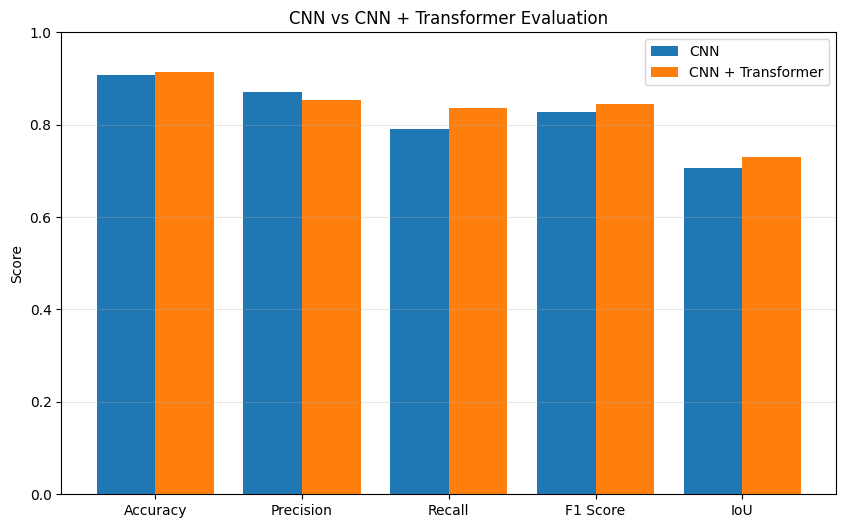

In [71]:
plt.figure(figsize=(10, 6))

x = range(len(comparison_df))

plt.bar(
    [i - 0.2 for i in x],
    comparison_df["CNN"],
    width=0.4,
    label="CNN"
)

plt.bar(
    [i + 0.2 for i in x],
    comparison_df["CNN + Transformer"],
    width=0.4,
    label="CNN + Transformer"
)

plt.xticks(x, comparison_df["Metric"])
plt.ylabel("Score")
plt.title("CNN vs CNN + Transformer Evaluation")
plt.ylim(0, 1)
plt.legend()
plt.grid(axis="y", alpha=0.3)

plt.show()

"In this experiment, adding the Transformer module improved accuracy, recall, F1-score, and IoU compared with the CNN baseline, while precision decreased slightly. The increase in recall suggests that the hybrid model detected more of the target flood pixels, while the lower precision indicates a modest increase in false-positive predictions."

1. Load synthetic dataset              ✅
2. Explore/visualize dataset           ✅
3. Train/validation/test split         ✅
4. Feature normalization               ✅
5. PyTorch Dataset & DataLoader        ✅
6. CNN baseline                        ✅
7. CNN training                        ✅
8. CNN evaluation                      ✅
9. CNN prediction visualization        ✅
10. CNN + Transformer model            ✅
11. Hybrid model training              ✅
12. Hybrid model evaluation            ✅
13. CNN vs Hybrid comparison           ✅